In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = "/home/kobugi/papaya/ece-5464/project_5/data/mushroom.csv"
df = pd.read_csv(path)

In [3]:
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 poisonous                   0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises?                    0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


In [4]:
question_marks = df.map(lambda x: x == "?")
question_mark_count = question_marks.sum()
print("Number of '?' values per column:\n", question_mark_count)

Number of '?' values per column:
 poisonous                      0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises?                       0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64


In [12]:
for col in df.columns:
    unique_vals = df[col].unique()
    num_unique = df[col].nunique()
    print(f"{col}: {num_unique} unique vals: {unique_vals}")

poisonous: 2 unique vals: ['p' 'e']
cap-shape: 6 unique vals: ['x' 'b' 's' 'f' 'k' 'c']
cap-surface: 4 unique vals: ['s' 'y' 'f' 'g']
cap-color: 10 unique vals: ['n' 'y' 'w' 'g' 'e' 'p' 'b' 'u' 'c' 'r']
bruises?: 2 unique vals: ['t' 'f']
odor: 9 unique vals: ['p' 'a' 'l' 'n' 'f' 'c' 'y' 's' 'm']
gill-attachment: 2 unique vals: ['f' 'a']
gill-spacing: 2 unique vals: ['c' 'w']
gill-size: 2 unique vals: ['n' 'b']
gill-color: 12 unique vals: ['k' 'n' 'g' 'p' 'w' 'h' 'u' 'e' 'b' 'r' 'y' 'o']
stalk-shape: 2 unique vals: ['e' 't']
stalk-root: 4 unique vals: ['e' 'c' 'b' 'r']
stalk-surface-above-ring: 4 unique vals: ['s' 'f' 'k' 'y']
stalk-surface-below-ring: 4 unique vals: ['s' 'f' 'y' 'k']
stalk-color-above-ring: 9 unique vals: ['w' 'g' 'p' 'n' 'b' 'e' 'o' 'c' 'y']
stalk-color-below-ring: 9 unique vals: ['w' 'p' 'g' 'b' 'n' 'e' 'y' 'o' 'c']
veil-type: 1 unique vals: ['p']
veil-color: 4 unique vals: ['w' 'n' 'o' 'y']
ring-number: 3 unique vals: ['o' 't' 'n']
ring-type: 5 unique vals: ['p' 'e'

In [6]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

df['stalk-root'] = df['stalk-root'].replace('?', np.nan)

df_temp = df.copy()

ordinal = OrdinalEncoder()
encoded = ordinal.fit_transform(df_temp[['stalk-root']])

df_temp['stalk-root'] = encoded

imputer = KNNImputer(n_neighbors=5)
imputed = imputer.fit_transform(df_temp[['stalk-root']])

decoded = ordinal.inverse_transform(imputed)

df['stalk-root'] = decoded.ravel()

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

featurenames = df.columns.tolist()
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
preprocessor = Pipeline([
   ('encoder', encoder)
])
X = preprocessor.fit_transform(df[featurenames])

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  
X_reduced = pca.fit_transform(X)

Clusters: 2, Silhouette Score: 0.189
Clusters: 3, Silhouette Score: 0.227
Clusters: 4, Silhouette Score: 0.192
Clusters: 5, Silhouette Score: 0.259
Clusters: 6, Silhouette Score: 0.282
Clusters: 7, Silhouette Score: 0.209
Clusters: 8, Silhouette Score: 0.300
Clusters: 9, Silhouette Score: 0.318
Clusters: 10, Silhouette Score: 0.199
Clusters: 11, Silhouette Score: 0.211
Clusters: 12, Silhouette Score: 0.203
Clusters: 13, Silhouette Score: 0.225
Clusters: 14, Silhouette Score: 0.217
Clusters: 15, Silhouette Score: 0.217
Clusters: 16, Silhouette Score: 0.172
Clusters: 17, Silhouette Score: 0.176
Clusters: 18, Silhouette Score: 0.185
Clusters: 19, Silhouette Score: 0.173
Clusters: 20, Silhouette Score: 0.156
Clusters: 21, Silhouette Score: 0.158
Clusters: 22, Silhouette Score: 0.140
Clusters: 23, Silhouette Score: 0.149
Clusters: 24, Silhouette Score: 0.168


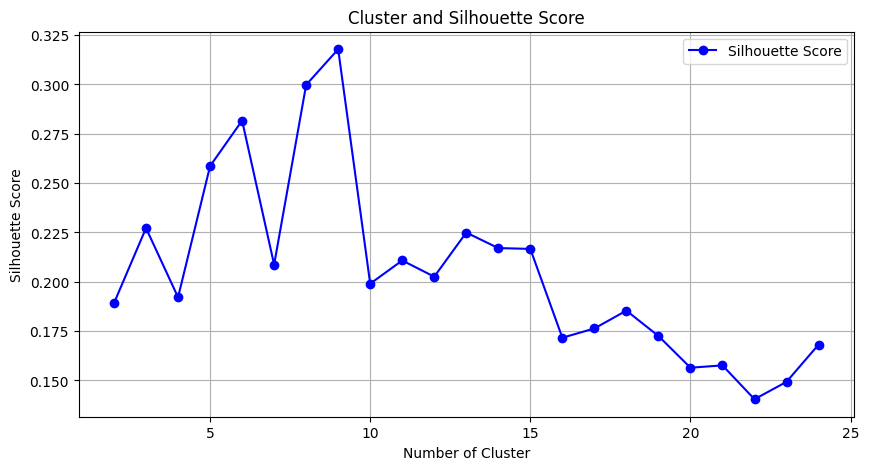

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


cluster = []
ss = []

for k in range(2, 25):
    clus = KMeans(n_clusters=k)
    labels = clus.fit_predict(X_reduced)
    score = silhouette_score(X_reduced, labels)
    print(f"Clusters: {k}, Silhouette Score: {score:.3f}")
    cluster.append(k)  
    ss.append(score) 

plt.figure(figsize=(10, 5))
plt.plot(cluster, ss, marker='o', linestyle='-', color='b', label='Silhouette Score')

plt.xlabel("Number of Cluster")
plt.ylabel("Silhouette Score")
plt.title("Cluster and Silhouette Score")
plt.legend()
plt.grid(True)
plt.show()

Clusters: 2, Silhouette Score: 0.186
Clusters: 3, Silhouette Score: 0.227
Clusters: 4, Silhouette Score: 0.227
Clusters: 5, Silhouette Score: 0.260
Clusters: 6, Silhouette Score: 0.281
Clusters: 7, Silhouette Score: 0.291
Clusters: 8, Silhouette Score: 0.308
Clusters: 9, Silhouette Score: 0.317
Clusters: 10, Silhouette Score: 0.323
Clusters: 11, Silhouette Score: 0.326
Clusters: 12, Silhouette Score: 0.327
Clusters: 13, Silhouette Score: 0.326
Clusters: 14, Silhouette Score: 0.286
Clusters: 15, Silhouette Score: 0.244
Clusters: 16, Silhouette Score: 0.194
Clusters: 17, Silhouette Score: 0.198
Clusters: 18, Silhouette Score: 0.199
Clusters: 19, Silhouette Score: 0.203
Clusters: 20, Silhouette Score: 0.203
Clusters: 21, Silhouette Score: 0.207
Clusters: 22, Silhouette Score: 0.203
Clusters: 23, Silhouette Score: 0.209
Clusters: 24, Silhouette Score: 0.187


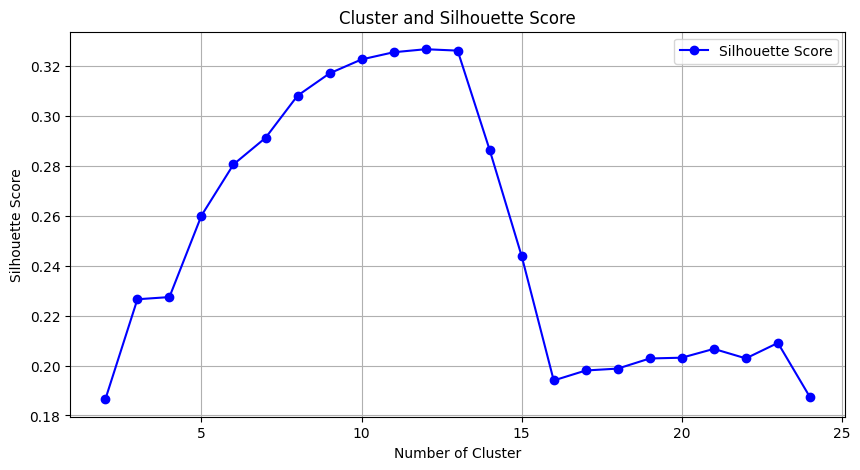

In [10]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

cluster = []
ss = []

for k in range(2, 25):
    clus = AgglomerativeClustering(n_clusters=k)
    labels = clus.fit_predict(X_reduced)
    score = silhouette_score(X_reduced, labels)
    print(f"Clusters: {k}, Silhouette Score: {score:.3f}")
    cluster.append(k)  
    ss.append(score)  

plt.figure(figsize=(10, 5))
plt.plot(cluster, ss, marker='o', linestyle='-', color='b', label='Silhouette Score')

plt.xlabel("Number of Cluster")
plt.ylabel("Silhouette Score")
plt.title("Cluster and Silhouette Score")
plt.legend()
plt.grid(True)
plt.show()